In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gymnasium_driving

import src.environments.helpers.random

ModuleNotFoundError: No module named 'gymnasium_driving'

In [ ]:
env = gymnasium_driving.CarEnvironment(
    model="bicycle",
    road_network=gymnasium_driving.components.roads.RoadNetwork(
        roads=[gymnasium_driving.components.roads.Road(
            segments=[
                gymnasium_driving.components.roads.StraightSegment(
                    start=(10.0, 50.0),
                    heading=0.0,
                    length=100,
                )
            ],
            width=8.0,
        )],
    ),
    # road_network=gymnasium_driving.components.roads.RoadNetwork(
    #     roads=[
    #         gymnasium_driving.components.roads.create_rectangular_track(
    #             center=(50, 50),
    #             length=75,
    #             height=75,
    #             turn_radius=8.0,
    #             width=8.0,
    #         )
    #     ],
    # ),
    render_mode="rgb_array",
    proportion=(0.90, 0.00),
    noise=(0.0, 0.0),
    obstacles=[],
)
env = src.environments.helpers.random.RandomWaypointObstacles(env)

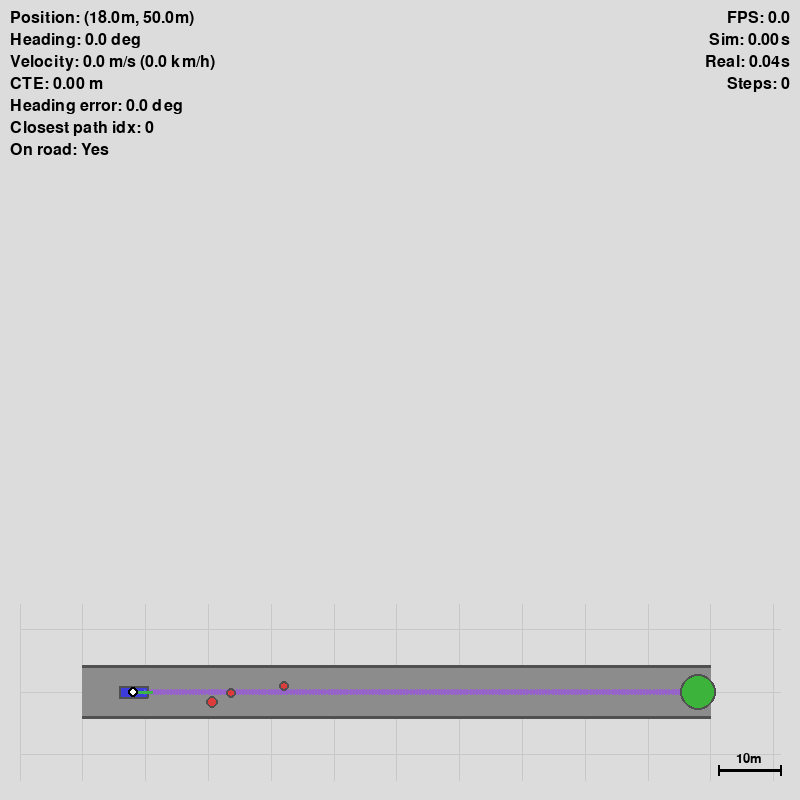

In [ ]:
env.reset()
helpers.preview(env)

In [70]:
print("/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-13/19-38-59")
print("/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/15-40-08")
print("/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/14-08-35")

/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-13/19-38-59
/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/15-40-08
/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/14-08-35


In [1]:
# NOTE: able to avoid obstacles
# /Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-13/19-38-59
# /Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/15-40-08

# NOTE: able to follow a path
# /Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/14-08-35

# HYDRA_FULL_ERROR=1 python train.py \
#   environment@train=straight \
#   environment@eval=straight \
#   train.discrete=true \
#   eval.discrete=true
#   controller=dqn \
#   reward=path_progress_obstacles \
#   total_timesteps=1000000 \

In [2]:
import sys

if "../" not in sys.path:
    sys.path.append("../")

In [3]:
print("[sys.path]:", sys.path)

[sys.path]: ['/Users/nadir/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12', '/Users/nadir/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages', '/Users/nadir/Documents/research-project/code/experimentations/gymnasium/src', '../']


In [4]:
import os
import time
import tqdm

import src
import src.helpers as helpers
import src.environments.cristal as cristal

import src.controllers.dqn as dqn
import src.controllers.ppo as ppo
import src.controllers.clothoids as clothoids
import src.controllers.purepursuit as purepursuit

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

objc[38415]: Class SDLApplication is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x107d612c8) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x14b25c890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[38415]: Class SDLAppDelegate is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x107d61318) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x14b25c8e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[38415]: Class SDLTransl

In [5]:
# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/13-59-36/"

# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/21-12-59" # learned wit a static obstacle
# path = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-08/20-54-02" # learned with random obstacles

In [6]:

output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/14-50-04"
output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/multirun/2026-02-09/15-26-19"
output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/16-30-57"

# NOTE: very good path follower, no obstacle avoidance
output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/19-05-24"

output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/19-45-59"

output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-09/21-56-50"

output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-12/15-25-48/"

output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-12/16-33-29"

output_directory = helpers.get_last_run_directory(
    base_directory="/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs",
    script="train"
)

# output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-14/14-08-35"
# output_directory = "/Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-13/14-41-42"

print("[output_directory]:", output_directory)

best_model_path = os.path.join(output_directory, "best_model.zip")
print("[best_model_exists]:", os.path.exists(best_model_path), best_model_path)

configuration = helpers.load_configuration(
    output_directory=output_directory,
    expected_script="train",
)

controller, train_environment, eval_environment = helpers.instantiate_configuration(
    configuration=configuration,
    output_directory=output_directory,
    load_best_model=True
)

environment = train_environment

environment.unwrapped.render_mode = "rgb_array"

[output_directory]: /Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-15/16-32-03
[best_model_exists]: True /Users/nadir/Documents/research-project/code/experimentations/gymnasium/outputs/2026-02-15/16-32-03/best_model.zip
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [7]:
configuration.controller._target_

'src.controllers.dqn.DQNController'

In [8]:
configuration.reward

{'_target_': 'gymnasium_driving.wrappers.rewards.path_progress.PathProgressReward'}

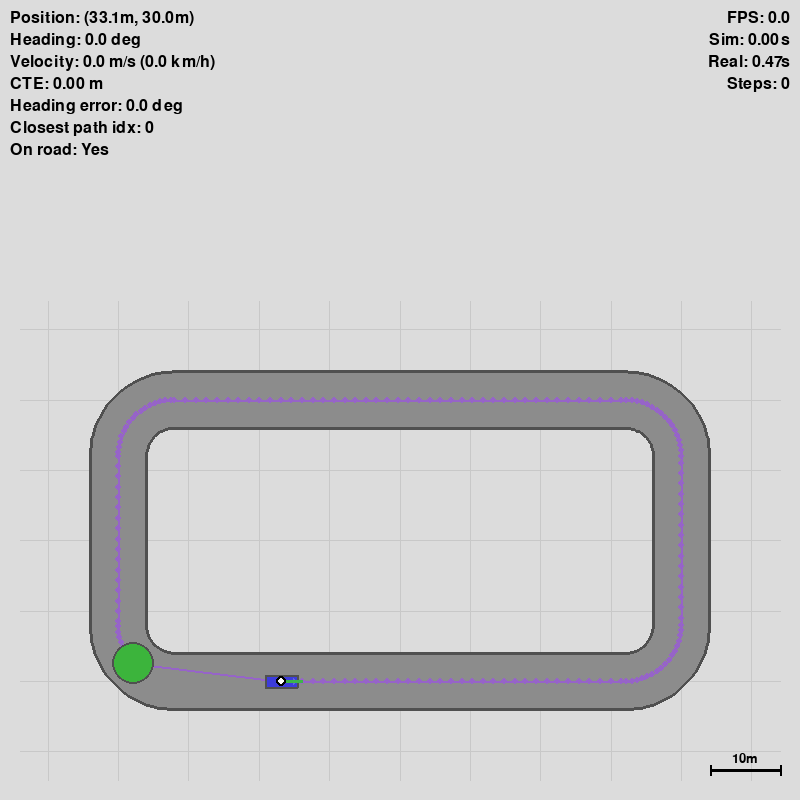

In [9]:
environment.reset()

helpers.preview(environment)

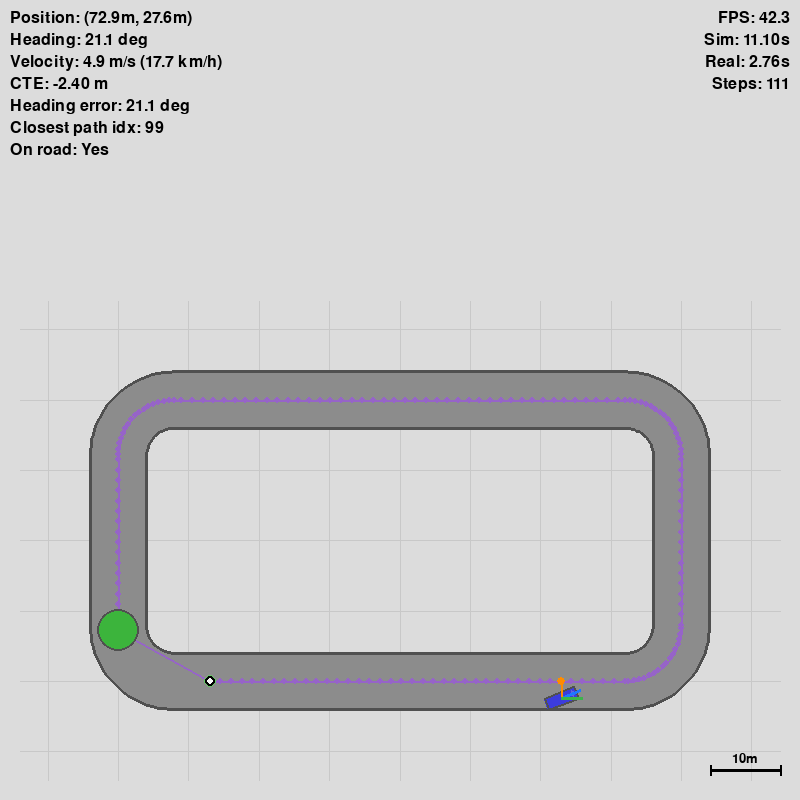

-77.2286644082718


In [11]:
observation, info = environment.reset()

total_reward = 0

for i in range(500):
    action, _states = controller.get_action(observation=observation)
    
    observation, reward, terminated, truncated, info = environment.step(action)
    
    total_reward += reward
    
    environment.unwrapped.overlay_manager.clear()
    controller.draw_debug(environment=environment, observation=observation, path=environment.unwrapped.path)
    
    helpers.preview(environment)
    
    if terminated or truncated:
        break

environment.close()

print(total_reward)